Upload your kaggle.json file

In [ ]:
# Create Kaggle folder
!mkdir -p ~/.kaggle

# Copy kaggle API key
!cp kaggle.json ~/.kaggle/

# Set permission
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Test if kaggle is working
!kaggle datasets list -s "poultry disease"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kausthubkannan/poultry-diseases-detection                        Poultry Diseases Detection                          8477371181  2023-04-05 11:50:51.357000           4168         43  0.875            
chandrashekarnatesh/poultry-diseases                             Poultry Pathology Visual Dataset                   13505230649  2023-11-10 02:39:42.143000           4158         39  1                
allandclive/chicken-disease-1                                    Chicken Disease Image Classification                 278791023  2022-04-03 19:49:20.373000           8671         82  0.5882353    

Importing the Poultry Pathology Visual Dataset

In [ ]:
# API to fecth the dataset from kaggle
!kaggle datasets download -d chandrashekarnatesh/poultry-diseases

Dataset URL: https://www.kaggle.com/datasets/chandrashekarnatesh/poultry-diseases
License(s): MIT
100% 12.6G/12.6G [10:07<00:00, 22.2MB/s]



In [ ]:
from zipfile import ZipFile

dataset = "/content/poultry-diseases.zip"

with ZipFile(dataset, "r") as zip:
    zip.extractall("poultry_dataset")
    print("The dataset is extracted")

The dataset is extracted


In [ ]:
# 1. Import libraries
import random
import numpy as np
import tensorflow as tf

# 2. Set random seeds
random.seed(42)
np.random.seed(0)
tf.random.set_seed(0)

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, BackupAndRestore, EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.image as mpimg
from google.colab import files
from PIL import Image

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
data_dir = "/content/poultry_dataset/data/data"

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

    if level >= 3:
        dirs[:] = []

data/
    val/
        Salmonella/
            salmo.2246.jpg_aug7.JPG
            pcrsalmo.318.jpg_aug41.JPG
            salmo.888.jpg_aug7.JPG
            salmo.300.jpg_aug4.JPG
            salmo.811.jpg_aug15.JPG
            salmo.1037.jpg_aug39.JPG
            salmo.49.jpg_aug44.JPG
            pcrsalmo.14.jpg_aug9.JPG
            salmo.1424.jpg_aug46.JPG
            salmo.1833.jpg_aug28.JPG
        Healthy/
            healthy.608.jpg_aug6.JPG
            healthy.343.jpg_aug37.JPG
            pcrhealthy.239.jpg_aug33.JPG
            healthy.1864.jpg_aug22.JPG
            healthy.1787.jpg_aug35.JPG
            pcrhealthy.150.jpg_aug16.JPG
            healthy.256.jpg_aug44.JPG
            healthy.918.jpg_aug19.JPG
            healthy.424.jpg_aug6.JPG
            healthy.1449.jpg_aug17.JPG
        Coccidiosis/
            cocci.2019.jpg_aug7.JPG
            cocci.1839.jpg_aug51.JPG
            cocci.284.jpg_aug44.JPG
            cocci.1236.jpg_aug2.JPG
            pcrcocci.9.jpg_aug9

In [ ]:
base_dir = "/content/poultry_dataset/data/data"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    split_dir = os.path.join(base_dir, split)

    total = 0

    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)

        if os.path.isdir(class_dir):
            count = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ])

            print(f"{class_name}: {count}")
            total += count

    print("Total:", total)


TRAIN
Coccidiosis: 100000
Healthy: 100000
New Castle Disease: 100000
Salmonella: 100000
Total: 400000

VAL
Coccidiosis: 10000
Healthy: 10000
New Castle Disease: 10000
Salmonella: 10000
Total: 40000

TEST
Coccidiosis: 18752
Healthy: 17412
New Castle Disease: 15888
Salmonella: 18625
Total: 70677


In [ ]:
image_path = "/content/poultry_dataset/data/data/test/Healthy/healthy.0.jpg_aug1.JPG"

print(os.path.exists(image_path))

True


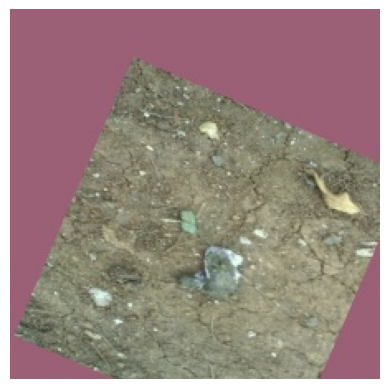

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Read the image
img = mpimg.imread(image_path)

# Display the image
plt.imshow(img)
plt.axis("off")

# Save the image
plt.savefig("saved_image.png", bbox_inches="tight")

# Show the image
plt.show()

# Download to your computer
from google.colab import files
files.download("saved_image.png")

In [ ]:
source_train = "/content/poultry_dataset/data/data/train"
subset_train = "/content/poultry_dataset/data/train_subset"

classes = [
    "Coccidiosis",
    "Healthy",
    "New Castle Disease",
    "Salmonella"
]

images_per_class = 5000

# Create subset folders
for class_name in classes:
    os.makedirs(
        os.path.join(subset_train, class_name),
        exist_ok=True
    )

In [ ]:
for class_name in classes:

    source_class = os.path.join(source_train, class_name)
    target_class = os.path.join(subset_train, class_name)

    images = [
        f for f in os.listdir(source_class)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    # Randomly select 5,000
    selected_images = random.sample(images, images_per_class)

    for filename in selected_images:
        shutil.copy2(
            os.path.join(source_class, filename),
            os.path.join(target_class, filename)
        )

    print(
        class_name,
        "→",
        len(selected_images),
        "images copied"
    )

print("\nSubset created:", subset_train)

Coccidiosis → 5000 images copied
Healthy → 5000 images copied
New Castle Disease → 5000 images copied
Salmonella → 5000 images copied

Subset created: /content/poultry_dataset/data/train_subset


In [ ]:
subset_train = "/content/poultry_dataset/data/train_subset"

classes = [
    "Coccidiosis",
    "Healthy",
    "New Castle Disease",
    "Salmonella"
]

for class_name in classes:
    path = os.path.join(subset_train, class_name)

    count = len([
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

    print(f"{class_name}: {count}")

print("Total:", sum(
    len([
        f for f in os.listdir(os.path.join(subset_train, c))
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])
    for c in classes
))

Coccidiosis: 5000
Healthy: 5000
New Castle Disease: 5000
Salmonella: 5000
Total: 20000


In [ ]:
# Image parameter
img_size = (224, 224)
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    subset_train,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    "/content/poultry_dataset/data/data/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    "/content/poultry_dataset/data/data/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 20000 images belonging to 4 classes.
Found 40000 images belonging to 4 classes.
Found 70677 images belonging to 4 classes.


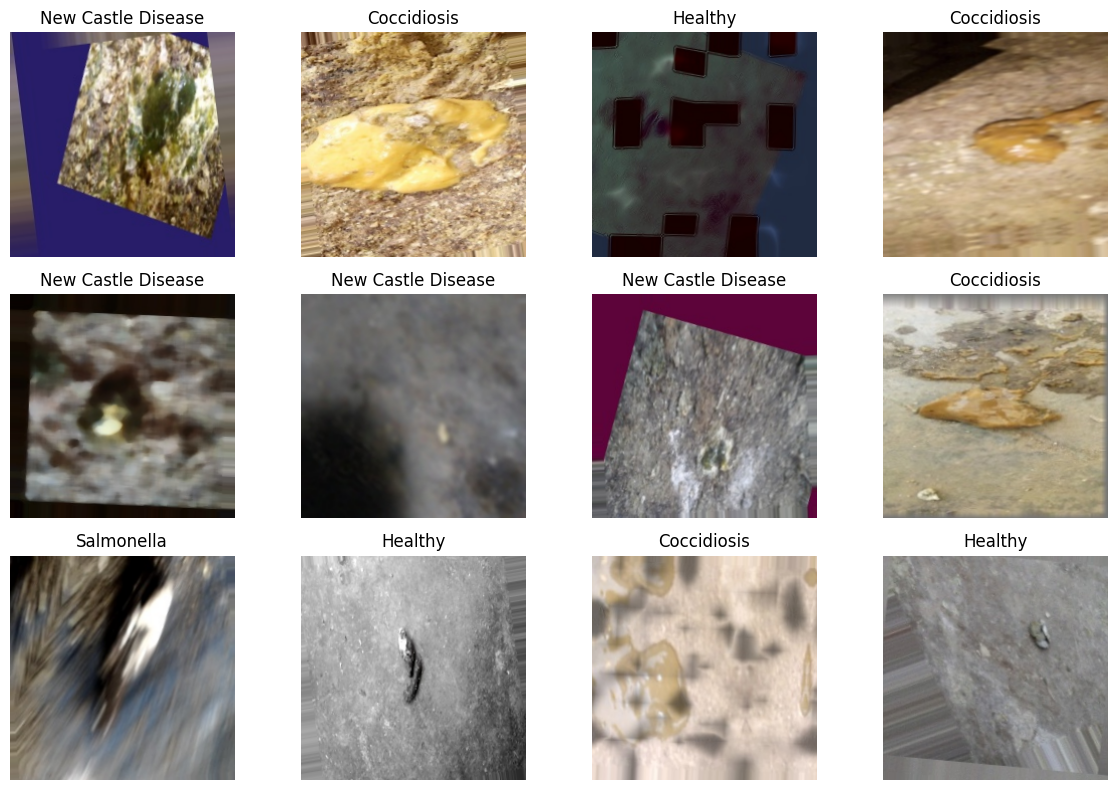

Class indices: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Image shape: (32, 224, 224, 3)
Label shape: (32, 4)
Image minimum: 0.0
Image maximum: 255.0


In [ ]:
images, labels = next(train_gen)

class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].astype("uint8"))

    class_index = np.argmax(labels[i])
    plt.title(class_names[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Class indices:", train_gen.class_indices)
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Image minimum:", images.min())
print("Image maximum:", images.max())

In [ ]:
print("Training samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Test samples:", test_gen.samples)

print("Training classes:", train_gen.class_indices)
print("Validation classes:", val_gen.class_indices)
print("Test classes:", test_gen.class_indices)

print("Training steps:", len(train_gen))
print("Validation steps:", len(val_gen))
print("Test steps:", len(test_gen))

Training samples: 20000
Validation samples: 40000
Test samples: 70677
Training classes: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Validation classes: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Test classes: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Training steps: 625
Validation steps: 1250
Test steps: 2209


Transfer Learning

In [ ]:
# Image dimensions
img_size = (224, 224, 3)

# Load pretrained EfficientNetB3
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_size,
    pooling="max"
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Freeze the pretrained layers
base_model.trainable = False

In [ ]:
# Build the classifier
model = Sequential([
    base_model,

    BatchNormalization(),

    Dense(256, activation="relu"),

    Dropout(0.4),

    Dense(4, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
initial_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/EfficientNet_Checkpoints/poultry_disease_EfficientNetB3_epoch10.keras"
)

fine_tuned_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/EfficientNet_Checkpoints/poultry_disease_EfficientNetB3_finetuned_epoch15.keras"
)

In [ ]:
import json

class_names = list(test_gen.class_indices.keys())

print(class_names)

CLASS_PATH = "/content/drive/MyDrive/EfficientNet_Checkpoints/class_names.json"

with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)

print("class_names.json saved successfully.")

['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella']
class_names.json saved successfully.


In [ ]:
initial_loss, initial_accuracy = initial_model.evaluate(
    test_gen,
    verbose=1
)

fine_tuned_loss, fine_tuned_accuracy = fine_tuned_model.evaluate(
    test_gen,
    verbose=1
)

print("\n========== MODEL COMPARISON ==========")

print(f"Initial Model")
print(f"Test Accuracy: {initial_accuracy:.4f}")
print(f"Test Loss:     {initial_loss:.4f}")

print("\nFine-Tuned Model")
print(f"Test Accuracy: {fine_tuned_accuracy:.4f}")
print(f"Test Loss:     {fine_tuned_loss:.4f}")

2209/2209 ━━━━━━━━━━━━━━━━━━━━ 208s 82ms/step - accuracy: 0.8034 - loss: 0.5129
2209/2209 ━━━━━━━━━━━━━━━━━━━━ 187s 78ms/step - accuracy: 0.8251 - loss: 0.4578

========== MODEL COMPARISON ==========
Initial Model
Test Accuracy: 0.8034
Test Loss:     0.5129

Fine-Tuned Model
Test Accuracy: 0.8251
Test Loss:     0.4578


In [ ]:
models = ["Initial Model", "Fine-Tuned Model"]

accuracies = [
    initial_accuracy,
    fine_tuned_accuracy
]

losses = [
    initial_loss,
    fine_tuned_loss
]


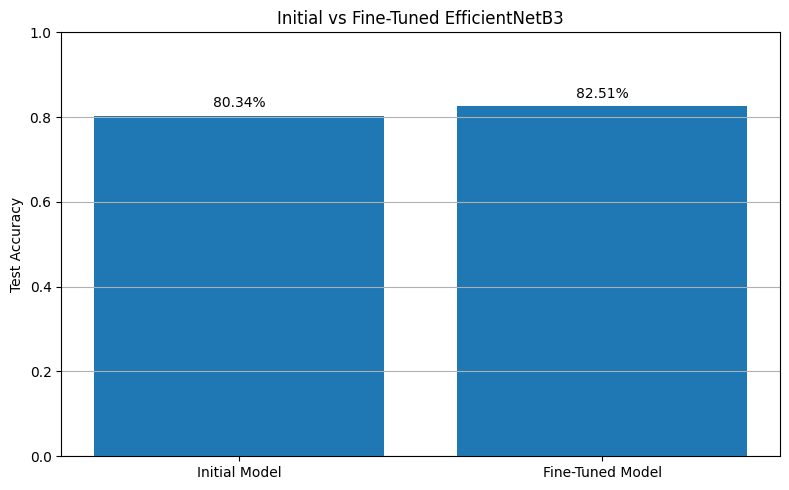

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Accuracy comparison
plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylabel("Test Accuracy")
plt.title("Initial vs Fine-Tuned EfficientNetB3")
plt.ylim(0, 1)
plt.grid(axis="y")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.tight_layout()

# Save picture in Google Colab
save_path = "/content/accuracy_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

# Download the picture to your computer
files.download(save_path)

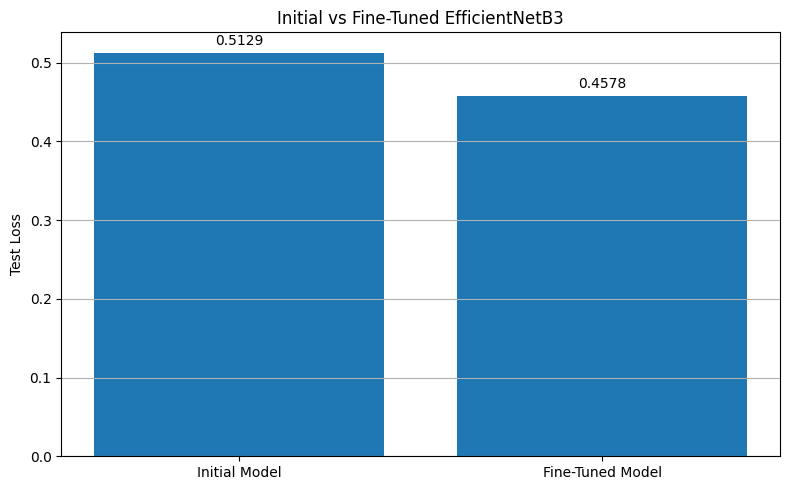

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Loss comparison
plt.figure(figsize=(8, 5))

plt.bar(models, losses)

plt.ylabel("Test Loss")
plt.title("Initial vs Fine-Tuned EfficientNetB3")
plt.grid(axis="y")

for i, value in enumerate(losses):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.tight_layout()

# Save picture in Google Colab
save_path = "/content/loss_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

# Download picture to your computer
files.download(save_path)

In [ ]:
# Initial model predictions
initial_predictions = initial_model.predict(
    test_gen,
    verbose=1
)

initial_predicted_classes = np.argmax(
    initial_predictions,
    axis=1
)

# Fine-tuned model predictions
fine_tuned_predictions = fine_tuned_model.predict(
    test_gen,
    verbose=1
)

fine_tuned_predicted_classes = np.argmax(
    fine_tuned_predictions,
    axis=1
)

# True labels
true_classes = test_gen.classes

# Class names
class_names = list(test_gen.class_indices.keys())

2209/2209 ━━━━━━━━━━━━━━━━━━━━ 193s 81ms/step
2209/2209 ━━━━━━━━━━━━━━━━━━━━ 188s 80ms/step


In [ ]:
print("========== INITIAL MODEL ==========")

print(
    classification_report(
        true_classes,
        initial_predicted_classes,
        target_names=class_names,
        digits=4
    )
)

print("\n========== FINE-TUNED MODEL ==========")

print(
    classification_report(
        true_classes,
        fine_tuned_predicted_classes,
        target_names=class_names,
        digits=4
    )
)

========== INITIAL MODEL ==========
                    precision    recall  f1-score   support

       Coccidiosis     0.9130    0.8335    0.8715     18752
           Healthy     0.7443    0.8200    0.7803     17412
New Castle Disease     0.7655    0.7522    0.7588     15888
        Salmonella     0.7952    0.8011    0.7981     18625

          accuracy                         0.8034     70677
         macro avg     0.8045    0.8017    0.8022     70677
      weighted avg     0.8072    0.8034    0.8044     70677


========== FINE-TUNED MODEL ==========
                    precision    recall  f1-score   support

       Coccidiosis     0.8896    0.8764    0.8830     18752
           Healthy     0.7812    0.8079    0.7943     17412
New Castle Disease     0.7926    0.7944    0.7935     15888
        Salmonella     0.8316    0.8158    0.8236     18625

          accuracy                         0.8251     70677
         macro avg     0.8238    0.8237    0.8236     70677
      weighted avg 

2209/2209 ━━━━━━━━━━━━━━━━━━━━ 172s 78ms/step
2209/2209 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step
========== MODEL COMPARISON ==========

Initial Model
Precision: 0.8045
Recall:    0.8017
F1-Score:  0.8022

Fine-Tuned Model
Precision: 0.8238
Recall:    0.8237
F1-Score:  0.8236


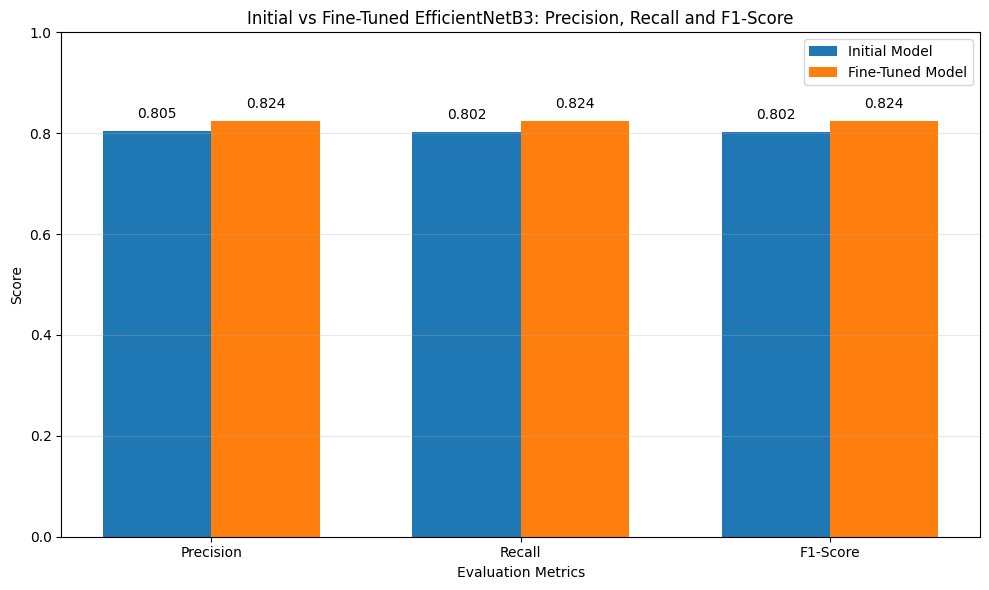

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --------------------------------------------------
# Predictions from the INITIAL model
# --------------------------------------------------

initial_predictions = initial_model.predict(
    test_gen,
    verbose=1
)

initial_predicted_classes = np.argmax(
    initial_predictions,
    axis=1
)

# --------------------------------------------------
# Predictions from the FINE-TUNED model
# --------------------------------------------------

fine_tuned_predictions = fine_tuned_model.predict(
    test_gen,
    verbose=1
)

fine_tuned_predicted_classes = np.argmax(
    fine_tuned_predictions,
    axis=1
)

# --------------------------------------------------
# True classes
# --------------------------------------------------

true_classes = test_gen.classes

# --------------------------------------------------
# Calculate macro-average metrics
# --------------------------------------------------

initial_precision = precision_score(
    true_classes,
    initial_predicted_classes,
    average="macro"
)

initial_recall = recall_score(
    true_classes,
    initial_predicted_classes,
    average="macro"
)

initial_f1 = f1_score(
    true_classes,
    initial_predicted_classes,
    average="macro"
)

fine_tuned_precision = precision_score(
    true_classes,
    fine_tuned_predicted_classes,
    average="macro"
)

fine_tuned_recall = recall_score(
    true_classes,
    fine_tuned_predicted_classes,
    average="macro"
)

fine_tuned_f1 = f1_score(
    true_classes,
    fine_tuned_predicted_classes,
    average="macro"
)

# --------------------------------------------------
# Store results
# --------------------------------------------------

metrics = ["Precision", "Recall", "F1-Score"]

initial_scores = [
    initial_precision,
    initial_recall,
    initial_f1
]

fine_tuned_scores = [
    fine_tuned_precision,
    fine_tuned_recall,
    fine_tuned_f1
]

# --------------------------------------------------
# Print results
# --------------------------------------------------

print("========== MODEL COMPARISON ==========")

print("\nInitial Model")
print(f"Precision: {initial_precision:.4f}")
print(f"Recall:    {initial_recall:.4f}")
print(f"F1-Score:  {initial_f1:.4f}")

print("\nFine-Tuned Model")
print(f"Precision: {fine_tuned_precision:.4f}")
print(f"Recall:    {fine_tuned_recall:.4f}")
print(f"F1-Score:  {fine_tuned_f1:.4f}")

# --------------------------------------------------
# Create grouped bar chart
# --------------------------------------------------

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    initial_scores,
    width,
    label="Initial Model"
)

bars2 = plt.bar(
    x + width/2,
    fine_tuned_scores,
    width,
    label="Fine-Tuned Model"
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.title(
    "Initial vs Fine-Tuned EfficientNetB3: "
    "Precision, Recall and F1-Score"
)

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add values on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()

# --------------------------------------------------
# Save picture in Google Colab
# --------------------------------------------------

save_path = "/content/precision_recall_f1_comparison.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

# --------------------------------------------------
# Download picture to your computer/desktop
# --------------------------------------------------

files.download(save_path)

In [ ]:
# Class names
class_names = [
    "Coccidiosis",
    "Healthy",
    "New Castle Disease",
    "Salmonella"
]


# Function to load and process an image

def load_and_process(image_path, target_size=(224, 224)):

    # Load the image
    new_img = Image.open(image_path)

    # Convert image to RGB
    new_img = new_img.convert("RGB")

    # Resize image
    new_img = new_img.resize(target_size)

    # Convert image to NumPy array
    img_array = np.array(new_img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    return new_img, img_array

In [ ]:
def predict_image(image_path):

    # Load and process image
    new_img, img_array = load_and_process(image_path)

    # Make prediction
    predictions = fine_tuned_model.predict(
        img_array,
        verbose=0
    )

    # Get predicted class
    predicted_index = np.argmax(predictions[0])

    predicted_class = class_names[predicted_index]

    # Get confidence
    confidence = predictions[0][predicted_index] * 100

    return new_img, predicted_class, confidence, predictions[0]

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

new_img, predicted_class, confidence, probabilities = predict_image(
    image_path
)

Saving saved_image.png to saved_image (1).png


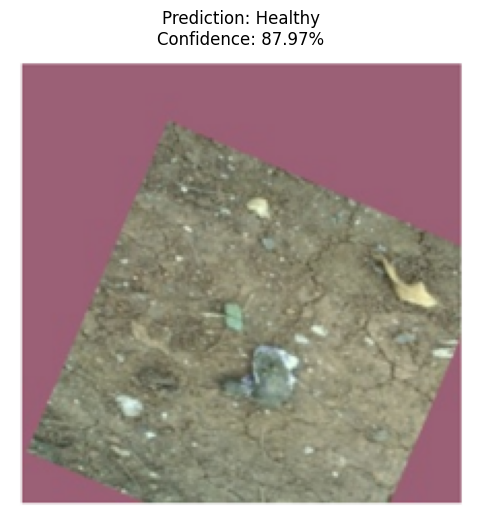

Prediction: Healthy
Confidence: 87.97%


In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(new_img)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [ ]:
import builtins

for class_name, probability in builtins.zip(
    class_names,
    probabilities
):
    print(f"{class_name}: {probability * 100:.2f}%")

Coccidiosis: 0.02%
Healthy: 87.97%
New Castle Disease: 2.50%
Salmonella: 9.50%
